In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap


e:\Faculdade\PISI3\projetodb\PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('..\\datasets_paralelos\\spotify_eda_7clusters.csv')

CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'instrumentalness',
    'liveness',
]

# Box Plots

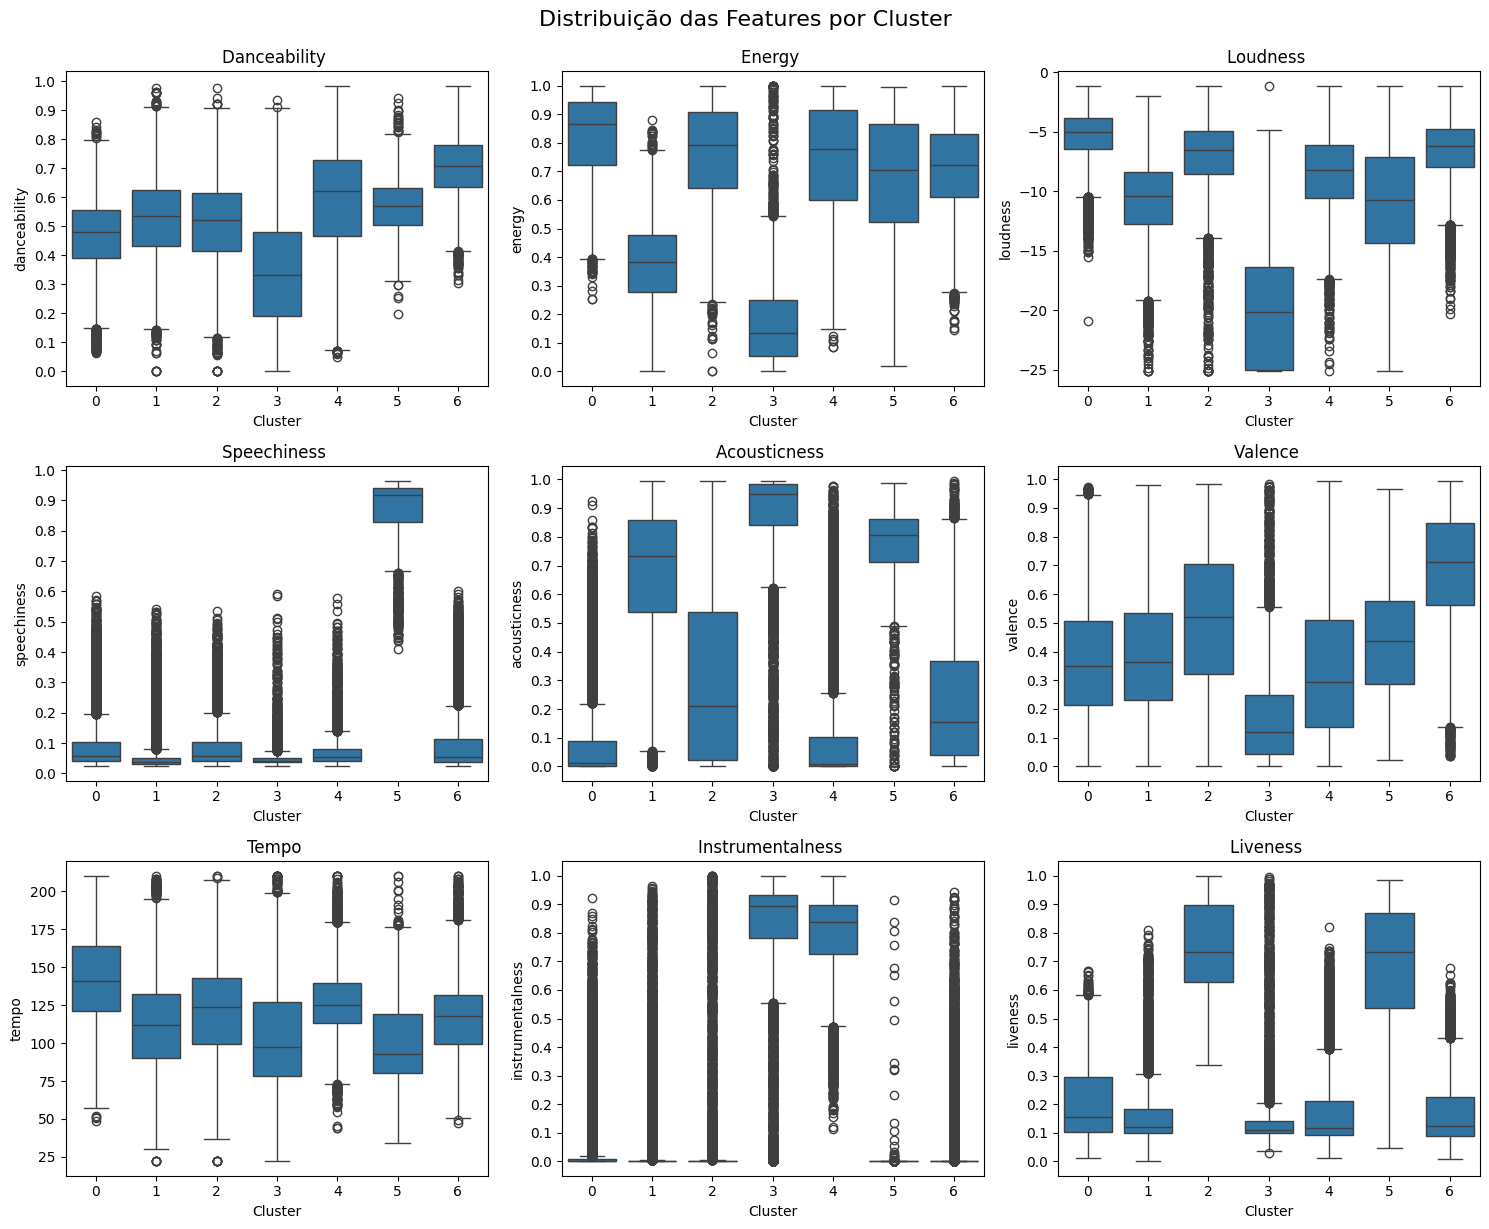

In [3]:

n_cols = 3
n_rows = (len(CLUSTER_FEATURES) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, feature in enumerate(CLUSTER_FEATURES, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x='cluster', y=feature)
    plt.title(f'{feature.capitalize()} ')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    
    # Define ticks do eixo Y de 0.0 até 1.0 com passo 0.1 (ajuste se necessário)
    min_val = df[feature].min()
    max_val = df[feature].max()
    
    # Só aplica se o range for compatível (evita erro no loudness ou tempo)
    if max_val - min_val < 2:
        plt.yticks(np.arange(0.0, 1.05, 0.1))

plt.tight_layout()
plt.suptitle('Distribuição das Features por Cluster', fontsize=16, y=1.02)
plt.show()


# HeatMap Clusters

In [4]:
mean_per_cluster = df.groupby('cluster')[CLUSTER_FEATURES].mean()
print(mean_per_cluster)

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.469431  0.823237  -5.265883     0.087265      0.076712   
1            0.526950  0.377415 -10.770643     0.054993      0.676414   
2            0.510126  0.758230  -7.109313     0.089068      0.296302   
3            0.350012  0.172838 -19.877060     0.052028      0.859484   
4            0.583621  0.744018  -8.516437     0.071468      0.102770   
5            0.572768  0.677006 -11.160786     0.848277      0.747311   
6            0.707050  0.714653  -6.567598     0.097677      0.227319   

          valence       tempo  instrumentalness  liveness  
cluster                                                    
0        0.371407  140.536930          0.040149  0.198096  
1        0.396194  113.312534          0.035289  0.160914  
2        0.507982  122.951179          0.081378  0.746837  
3        0.178348  103.382059          0.7

In [5]:
# Contagem de gêneros por cluster
genre_counts = df.groupby(['cluster', 'track_genre']).size().reset_index(name='count')

# Exibe agrupado por cluster
for c in sorted(df['cluster'].unique()):
    print(f'\n🎧 Cluster {c}:')
    
    cluster_genres = genre_counts[genre_counts['cluster'] == c].sort_values(by='count', ascending=False)
    
    # Mostra no notebook (visual bonito)
    display(cluster_genres.head(10))
    
    # Mostra como texto para copiar
    print(cluster_genres.head(10).to_string(index=False))



🎧 Cluster 0:


,cluster,track_genre,count
50,0,heavy-metal,706
49,0,hardstyle,637
22,0,death-metal,593
72,0,metalcore,571
44,0,grunge,546
46,0,happy,523
61,0,j-idol,491
28,0,dub,485
6,0,black-metal,483
27,0,drum-and-bass,463


 cluster   track_genre  count
       0   heavy-metal    706
       0     hardstyle    637
       0   death-metal    593
       0     metalcore    571
       0        grunge    546
       0         happy    523
       0        j-idol    491
       0           dub    485
       0   black-metal    483
       0 drum-and-bass    463

🎧 Cluster 1:


,cluster,track_genre,count
218,1,tango,720
125,1,cantopop,654
204,1,romance,629
163,1,honky-tonk,620
113,1,acoustic,591
209,1,show-tunes,529
181,1,mandopop,484
187,1,opera,431
128,1,chill,420
120,1,bluegrass,414


 cluster track_genre  count
       1       tango    720
       1    cantopop    654
       1     romance    629
       1  honky-tonk    620
       1    acoustic    591
       1  show-tunes    529
       1    mandopop    484
       1       opera    431
       1       chill    420
       1   bluegrass    414

🎧 Cluster 2:


...

 cluster    track_genre  count
       4 minimal-techno    739
       4 detroit-techno    714
       4          study    537
       4  chicago-house    501
       4      grindcore    490
       4            idm    473
       4    black-metal    417
       4         trance    406
       4      breakbeat    395
       4           club    359

🎧 Cluster 5:


,cluster,track_genre,count
515,5,comedy,802
555,5,show-tunes,27
541,5,kids,20
511,5,children,19
527,5,funk,16
526,5,french,15
518,5,disney,8
537,5,iranian,8
529,5,german,7
512,5,chill,6


 cluster track_genre  count
       5      comedy    802
       5  show-tunes     27
       5        kids     20
       5    children     19
       5        funk     16
       5      french     15
       5      disney      8
       5     iranian      8
       5      german      7
       5       chill      6

🎧 Cluster 6:


,cluster,track_genre,count
631,6,kids,741
660,6,salsa,717
586,6,dancehall,691
600,6,forro,661
590,6,disco,522
625,6,j-dance,514
566,6,afrobeat,512
579,6,children,500
630,6,k-pop,479
588,6,deep-house,470


 cluster track_genre  count
       6        kids    741
       6       salsa    717
       6   dancehall    691
       6       forro    661
       6       disco    522
       6     j-dance    514
       6    afrobeat    512
       6    children    500
       6       k-pop    479
       6  deep-house    470


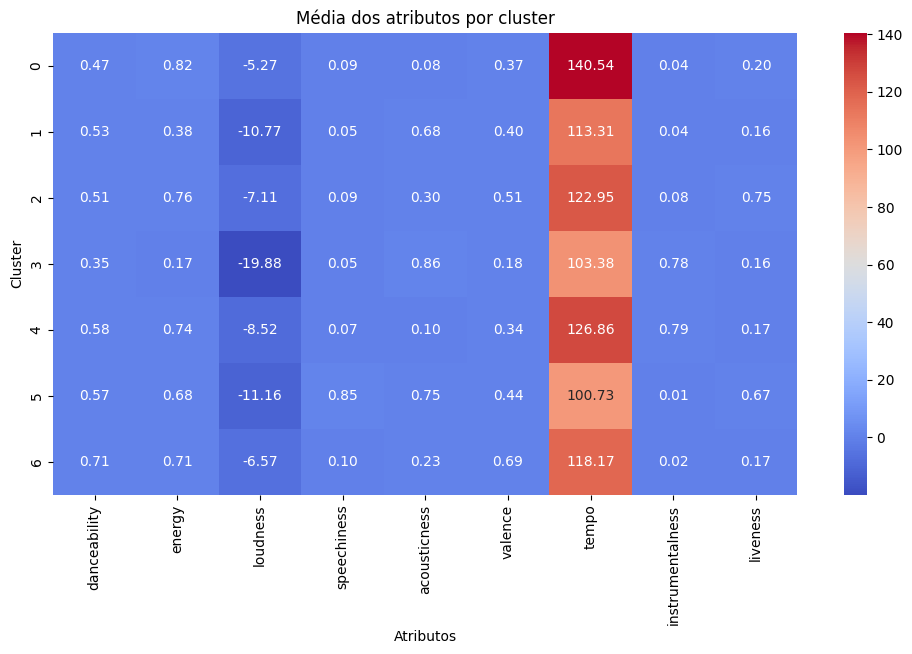

In [6]:
mean_values = df.groupby('cluster')[CLUSTER_FEATURES].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(mean_values, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Média dos atributos por cluster")
plt.ylabel("Cluster")
plt.xlabel("Atributos")
plt.show()

# Shap dos Clusters

100%|===================| 142341/142352 [100:34<00:00]       


Cluster 0


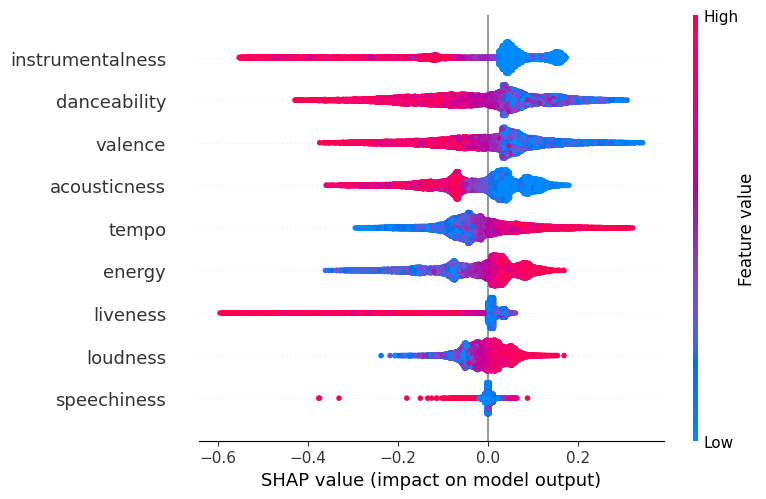


Cluster 1


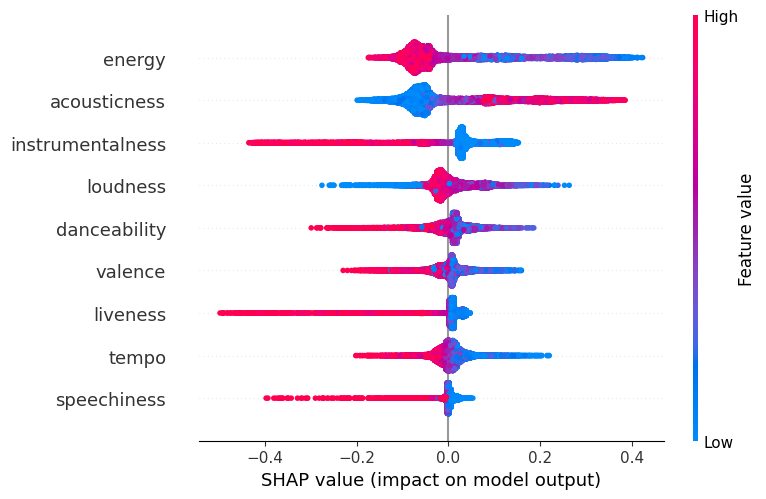


Cluster 2


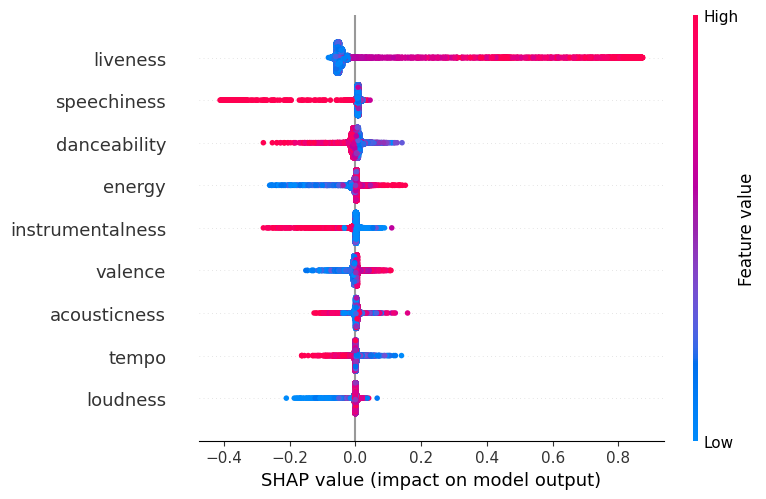


Cluster 3


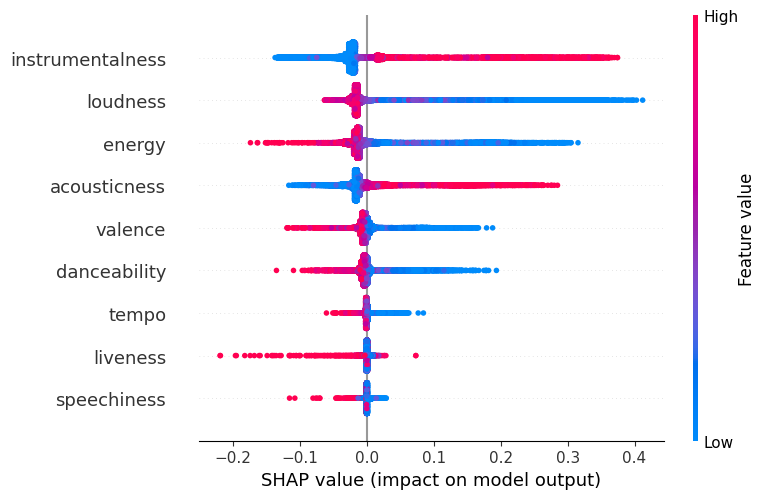


Cluster 4


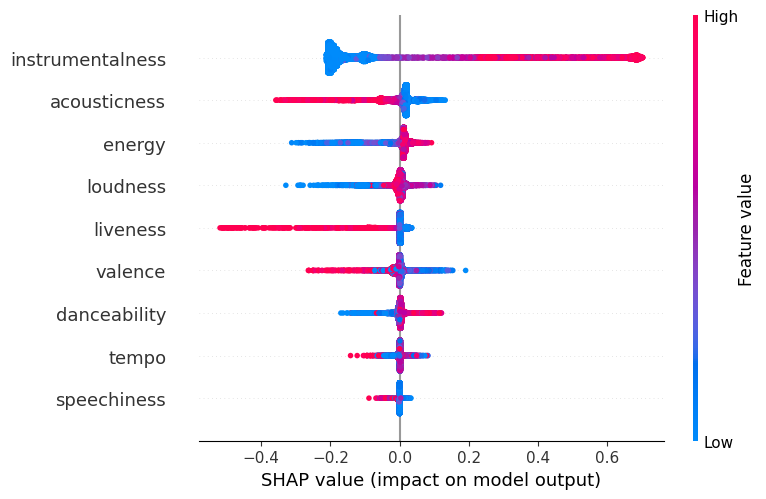


Cluster 5


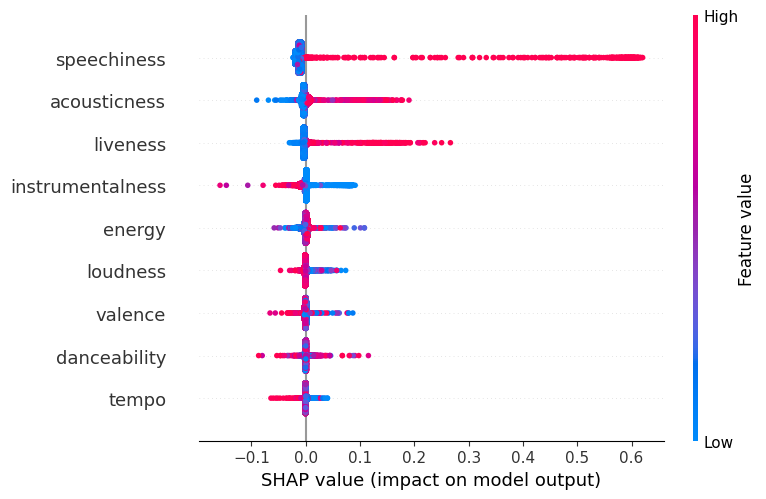


Cluster 6


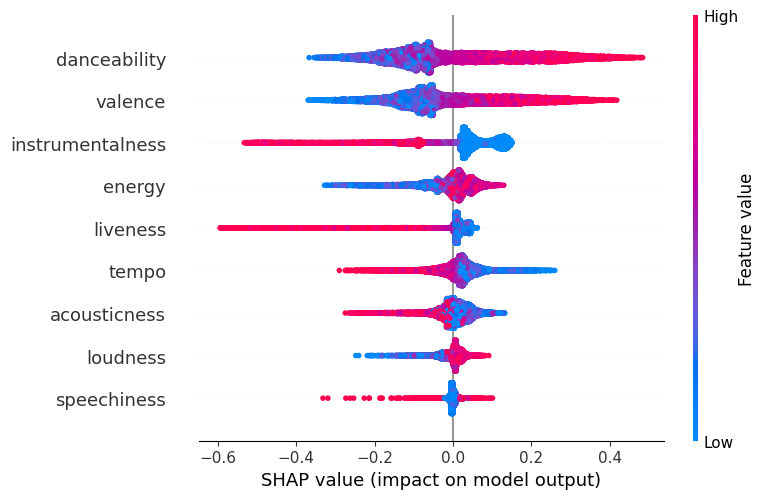


Waterfall plots por cluster:

Cluster 0 - Amostra índice 0


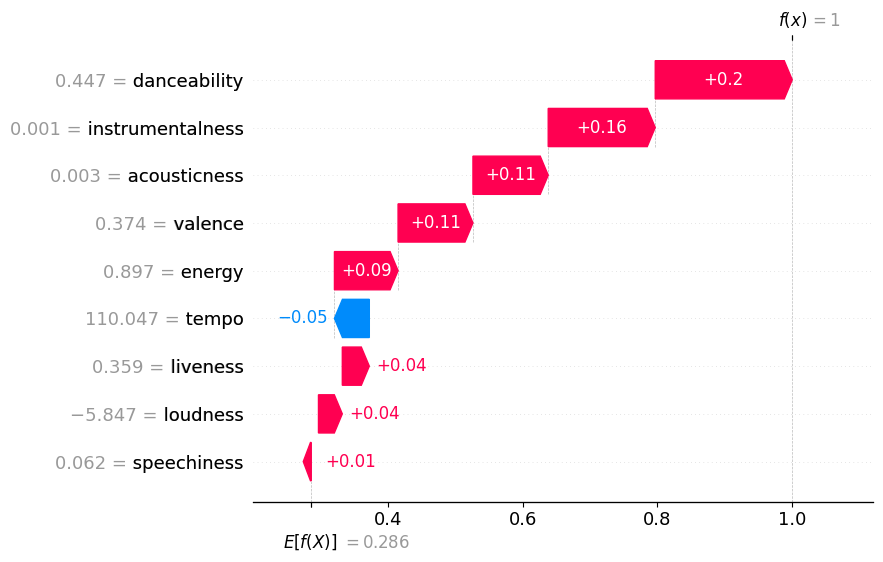


Cluster 1 - Amostra índice 2


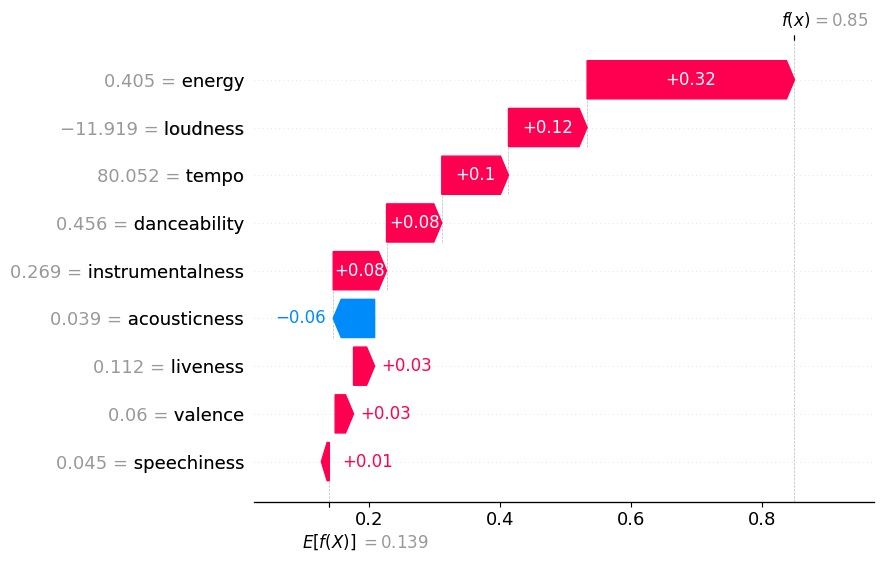


Cluster 2 - Amostra índice 32


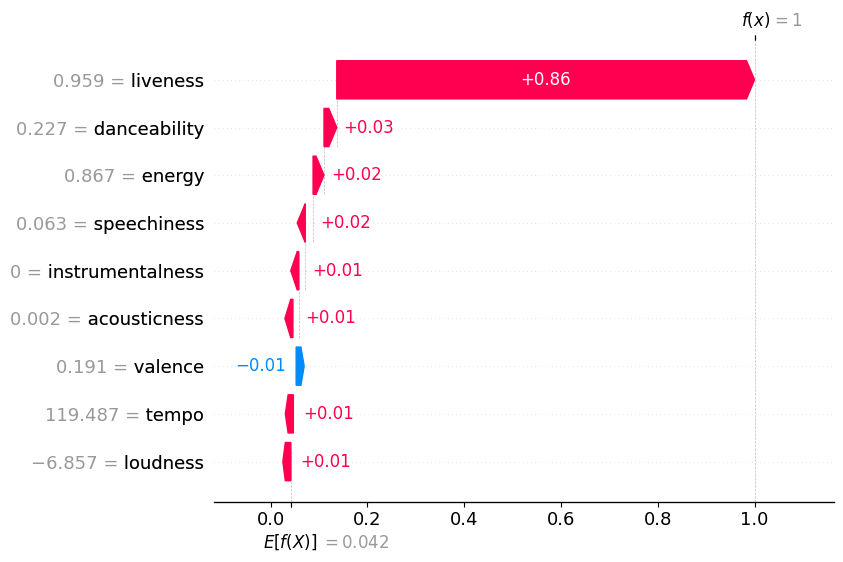


Cluster 3 - Amostra índice 1


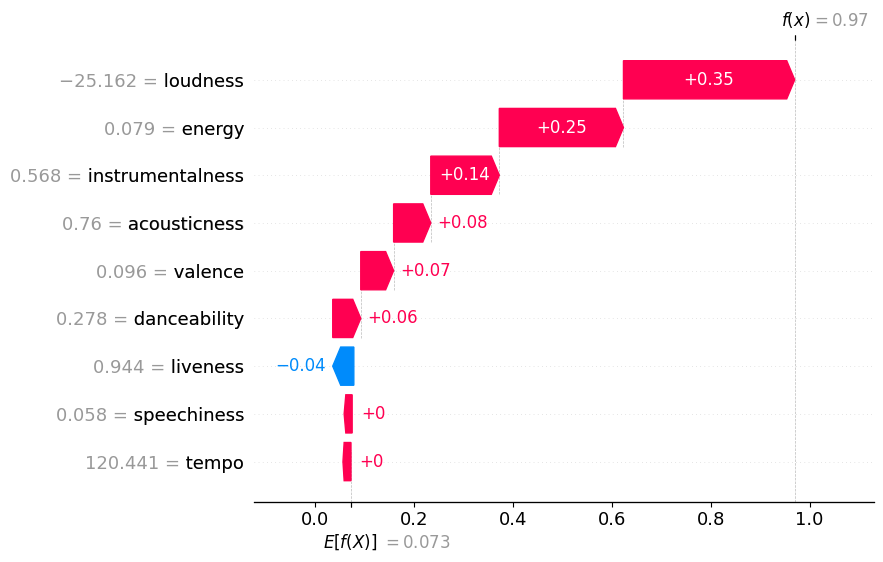


Cluster 4 - Amostra índice 10


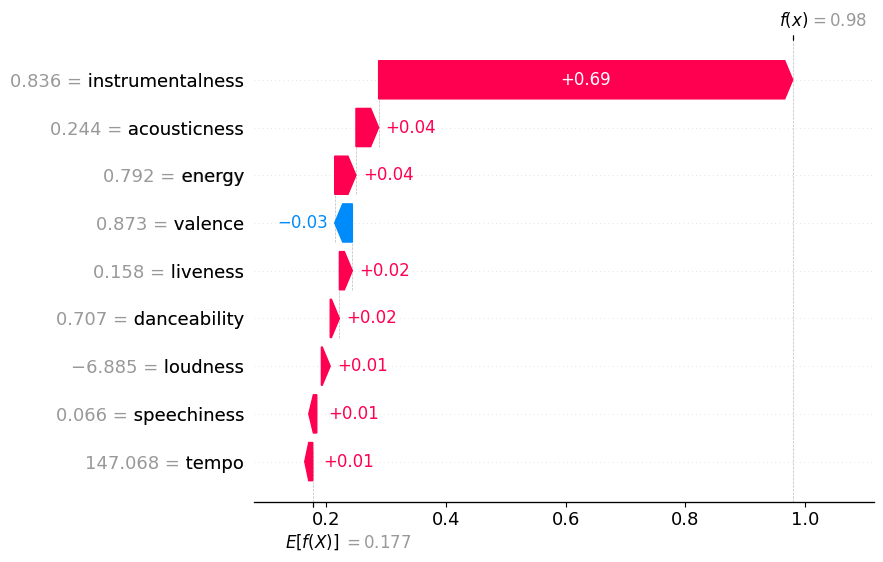


Cluster 5 - Amostra índice 37


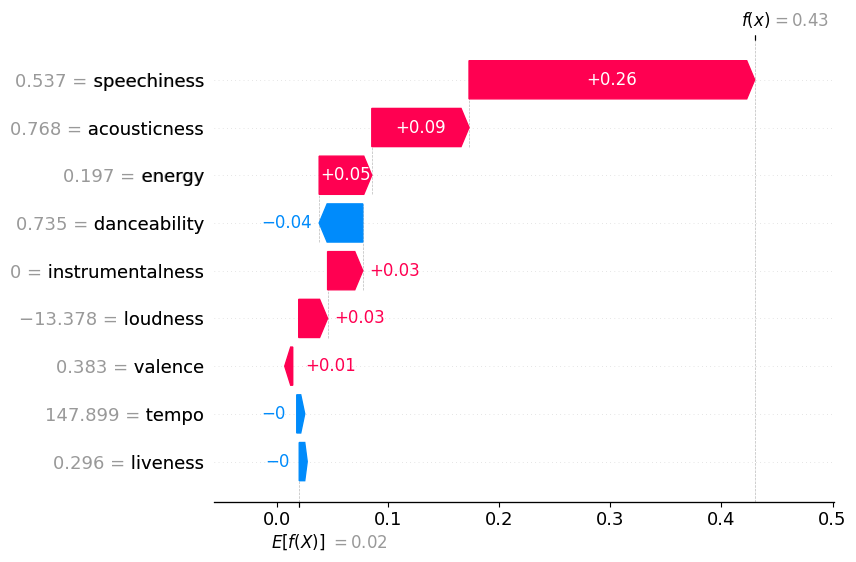


Cluster 6 - Amostra índice 4


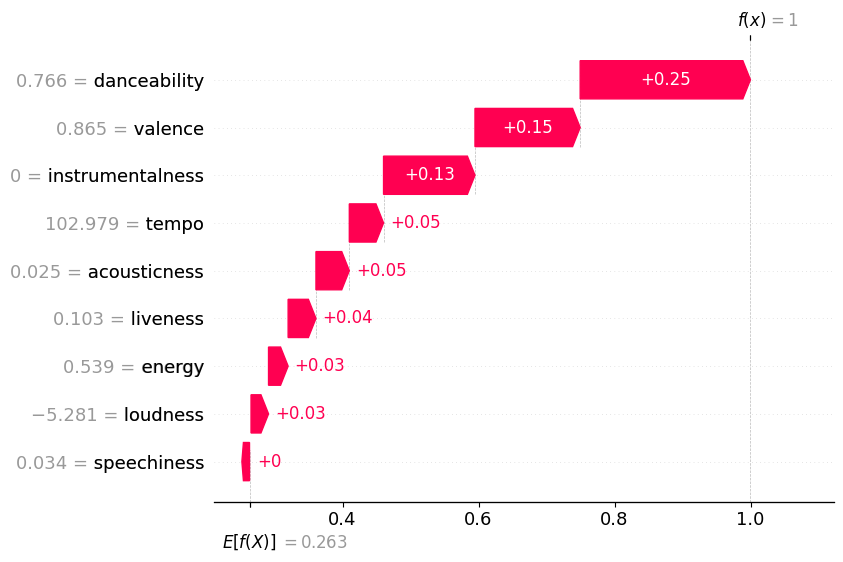

In [7]:
X = df[CLUSTER_FEATURES]
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)
n_clusters = len(set(y))


# === SUMMARY PLOTS POR CLUSTER ===
for i in range(n_clusters):
    print(f"\nCluster {i}")
    shap.summary_plot(shap_values[..., i], X_test, show=True)



print("\nWaterfall plots por cluster:")
for i in range(n_clusters):
    idx = np.where(y_test.values == i)[0]
    if len(idx) == 0:
        continue  
    sample_idx = idx[0]

    print(f"\nCluster {i} - Amostra índice {sample_idx}")
    shap.plots.waterfall(shap_values[sample_idx, :, i])